<div class="alert alert-block alert-success">
This notebook provides step-by-step instructions to deploy the NVIDIA AI Blueprint: Retail Agentic Commerce. Follow the cells in order to set up prerequisites, spin up the services, seed the vector database, and validate the deployment.
</div>

# Introduction

This notebook will deploy the **Retail Agentic Commerce** Blueprint using **local NVIDIA NIM containers** for on-premises LLM and embedding inference. The blueprint implements the **Agentic Commerce Protocol (ACP)**: a retailer-operated checkout system that enables agentic negotiation while maintaining merchant control.

**Deployment Mode: Local NIMs (On-Premises)**

This deployment runs NVIDIA NIM microservices locally on your GPU infrastructure:
- **Nemotron Nano LLM** (`nvidia/nemotron-3-nano`) - For agent reasoning and decisions
- **NV-EmbedQA E5** (`nvidia/nv-embedqa-e5-v5`) - For product catalog embeddings and search

You will:
- Install the necessary prerequisites (including NVIDIA Container Toolkit for GPU access)
- Spin up the NVIDIA Inference Microservices (NIMs) locally on your GPUs
- Start business logic services and supporting infrastructure
- Automatically seed the Milvus vector database with product embeddings
- Validate the deployment with health checks and the demo UI

Once deployed, you will have a fully functional reference implementation where AI agents can:
- **Interact with Client Agents** via Agentic Commerce protocol
- **Request promotions and discounts** via the Promotion Agent
- **Get personalized recommendations** via the ARAG-powered Recommendation Agent
- **Complete checkout** with delegated payments through the PSP Service
- **Receive multilingual post-purchase updates** via the Post-Purchase Agent

# Getting Started

>[Prerequisites](#Prerequisites)  
>[Spin Up Blueprint (Local NIM Deployment)](#Spin-Up-Blueprint-Local-NIM-Deployment)  
>[Validate Deployment](#Validate-Deployment)  
>[Service Ports Reference](#Service-Ports-Reference)  
>[Next Steps](#Next-Steps)  
>[Shutting Down Blueprint](#Shutting-Down-Blueprint)  

________________________

<a id="Prerequisites"></a>
## Prerequisites

### Clone repository and install software

1. **Clone** the Retail Agentic Commerce Git repository

In [ ]:
!git clone https://github.com/NVIDIA-AI-Blueprints/Retail-Agentic-Commerce.git
%cd Retail-Agentic-Commerce

2. Install **[Docker](https://docs.docker.com/engine/install/ubuntu/)**

<div class="alert alert-block alert-success">
    <b>Tip:</b> Ensure the Docker Compose plugin version is 2.29.1 or higher. Run <code>docker compose version</code> to confirm. Refer to <a href="https://docs.docker.com/compose/install/">Install the Compose plugin</a> Docker documentation for more information.
</div>

3. Install **[NVIDIA Container Toolkit](https://docs.nvidia.com/datacenter/cloud-native/container-toolkit/latest/install-guide.html#installing-the-nvidia-container-toolkit)** to configure Docker for GPU-accelerated containers.

If you are using a system deployed with Brev, you can skip this step since Brev systems come with NVIDIA Container Toolkit preinstalled.

<div class="alert alert-block alert-info">
    <b>Note:</b> After installing the toolkit, follow the instructions in the <a href="https://docs.nvidia.com/datacenter/cloud-native/container-toolkit/latest/install-guide.html#configuring-docker">Configure Docker</a> section in the NVIDIA Container Toolkit documentation.
</div>

<div class="alert alert-block alert-warning">
    <b>Important:</b> Step 3 is <b>REQUIRED</b> for this deployment because we are using local NVIDIA NIMs (on-prem deployment). The NVIDIA Container Toolkit enables GPU access for the NIM containers that run the LLM and embedding models locally.
</div>

### Get API Keys

The NVIDIA API Key is required for:
- Logging into the NVIDIA container registry (nvcr.io) to pull NIM container images
- Authenticating with NGC to download model weights on first NIM startup

<div class="alert alert-block alert-info">
    <b>Local NIM Deployment:</b> Since we're running NIMs locally, the API key is used only for pulling containers and downloading models. After initial setup, the NIMs run entirely on your local GPU infrastructure without cloud API calls.
</div>

Refer to [Generating NGC API Keys](https://docs.nvidia.com/ngc/gpu-cloud/ngc-user-guide/index.html#generating-api-key) in the NVIDIA NGC User Guide for more information.

1. Navigate to **[NVIDIA API Catalog](https://build.nvidia.com/explore/discover)**.

2. Select a model, such as **llama-3.1-8b-instruct**.

3. Select an **Input** option. The following example is of a model that offers a Docker option. Not all of the models offer this option, but all include a "Get API Key" link.

<img src="https://docscontent.nvidia.com/dims4/default/d6307a8/2147483647/strip/true/crop/1920x919+0+0/resize/2880x1378!/format/webp/quality/90/?url=https%3A%2F%2Fk3-prod-nvidia-docs.s3.us-west-2.amazonaws.com%2Fbrightspot%2Fsphinx%2F00000192-bfa6-da2c-a1f2-ffbf41aa0000%2Fnim%2Flarge-language-models%2Flatest%2F_images%2Fbuild_docker_tab.png" />

4. Click **Get API Key**.

<img src="https://docscontent.nvidia.com/dims4/default/c6e2096/2147483647/strip/true/crop/1920x919+0+0/resize/2880x1378!/format/webp/quality/90/?url=https%3A%2F%2Fk3-prod-nvidia-docs.s3.us-west-2.amazonaws.com%2Fbrightspot%2Fsphinx%2F00000192-bfa6-da2c-a1f2-ffbf41aa0000%2Fnim%2Flarge-language-models%2Flatest%2F_images%2Fbuild_get_api_key.png" />

5. Select **"Generate Key"**

<img src="https://docscontent.nvidia.com/dims4/default/e7c4057/2147483647/strip/true/crop/1920x919+0+0/resize/2880x1378!/format/webp/quality/90/?url=https%3A%2F%2Fk3-prod-nvidia-docs.s3.us-west-2.amazonaws.com%2Fbrightspot%2Fsphinx%2F00000192-bfa6-da2c-a1f2-ffbf41aa0000%2Fnim%2Flarge-language-models%2Flatest%2F_images%2Fbuild_generate_key.png" />

6. **Copy your key** and store it in a secure place. Do not share it.

<img src="https://docscontent.nvidia.com/dims4/default/4b0710a/2147483647/strip/true/crop/1920x919+0+0/resize/2880x1378!/format/webp/quality/90/?url=https%3A%2F%2Fk3-prod-nvidia-docs.s3.us-west-2.amazonaws.com%2Fbrightspot%2Fsphinx%2F00000192-bfa6-da2c-a1f2-ffbf41aa0000%2Fnim%2Flarge-language-models%2Flatest%2F_images%2Fbuild_copy_key.png" />

<div class="alert alert-block alert-success">
    <b>Tip:</b> The key begins with the letters <code>nvapi-</code>.
</div>

7. Export the API Key as an environment variable

In [ ]:
import getpass
import os

if not os.environ.get("NVIDIA_API_KEY", "").startswith("nvapi-"):
    nvidia_api_key = getpass.getpass("Enter your NVIDIA API key: ")
    assert nvidia_api_key.startswith("nvapi-"), f"{nvidia_api_key[:5]}... is not a valid key"
    os.environ["NVIDIA_API_KEY"] = nvidia_api_key

# Also set NGC_API_KEY for container registry authentication
os.environ["NGC_API_KEY"] = os.environ.get("NVIDIA_API_KEY")

### Let's log into the NVIDIA Container Registry

Authenticate with the NVIDIA Container Registry with the following command:

In [ ]:
!docker login nvcr.io --username '$oauthtoken' --password $NVIDIA_API_KEY

### Environment Setup

Create the NIM cache directory and set appropriate permissions:

In [ ]:
import os

# Create NIM cache directory
local_nim_cache = os.path.expanduser("~/.cache/nim")
os.environ["LOCAL_NIM_CACHE"] = local_nim_cache
os.makedirs(local_nim_cache, exist_ok=True)
os.system(f"chmod a+w {local_nim_cache}")

print(f"NIM cache directory created at: {local_nim_cache}")

### Configure Environment

Copy the environment template and configure your settings:

In [ ]:
!cp env.example .env

Now update the `.env` file with your NVIDIA API key and configure for **local NIM deployment**.

This deployment uses local NVIDIA NIM containers (started via `docker-compose-nim.yml`) instead of the public NVIDIA API endpoints. The NAT agents (Promotion, Post-Purchase, Recommendation, Search) will connect to:

| Service | Container | Port | Model |
|---------|-----------|------|-------|
| LLM | `nemotron-nano` | 8000 | `nvidia/nemotron-3-nano` |
| Embeddings | `embedqa` | 8000 | `nvidia/nv-embedqa-e5-v5` |

<div class="alert alert-block alert-info">
    <b>Note:</b> The local NIM uses a different model name (<code>nvidia/nemotron-3-nano</code>) compared to the public endpoint (<code>nvidia/nemotron-3-nano-30b-a3b</code>).
</div>

In [ ]:
# Write the NVIDIA_API_KEY and configure for Docker deployment
import os

env_file = ".env"
nvidia_api_key = os.environ.get("NVIDIA_API_KEY", "")

# Read existing content
with open(env_file, "r") as f:
    content = f.read()

# Replace the placeholder with actual key
content = content.replace("NVIDIA_API_KEY=nvapi-xxx", f"NVIDIA_API_KEY={nvidia_api_key}")

# =============================================================================
# Docker Deployment URL Configuration
# Replace localhost URLs with Docker service names for container-to-container communication
# =============================================================================

# Webhook URL (Merchant -> UI)
content = content.replace(
    "WEBHOOK_URL=http://localhost:3000/api/webhooks/acp",
    "WEBHOOK_URL=http://ui:3000/api/webhooks/acp"
)

# Agent URLs (Merchant -> Agents)
content = content.replace("PROMOTION_AGENT_URL=http://localhost:8002", "PROMOTION_AGENT_URL=http://promotion-agent:8002")
content = content.replace("POST_PURCHASE_AGENT_URL=http://localhost:8003", "POST_PURCHASE_AGENT_URL=http://post-purchase-agent:8003")
content = content.replace("RECOMMENDATION_AGENT_URL=http://localhost:8004", "RECOMMENDATION_AGENT_URL=http://recommendation-agent:8004")
content = content.replace("SEARCH_AGENT_URL=http://localhost:8005", "SEARCH_AGENT_URL=http://search-agent:8005")

# Infrastructure URLs (Agents -> Infrastructure)
content = content.replace("PHOENIX_ENDPOINT=http://localhost:6006/v1/traces", "PHOENIX_ENDPOINT=http://phoenix:6006/v1/traces")
content = content.replace("MILVUS_URI=http://localhost:19530", "MILVUS_URI=http://milvus-standalone:19530")

# =============================================================================
# LOCAL NIM Deployment Configuration
# Replace public NVIDIA API endpoints with local NIM container URLs
# =============================================================================

# LLM Configuration (Nemotron Nano - local NIM)
content = content.replace(
    "NIM_LLM_BASE_URL=https://integrate.api.nvidia.com/v1",
    "NIM_LLM_BASE_URL=http://nemotron-nano:8000/v1"
)
content = content.replace(
    "NIM_LLM_MODEL_NAME=nvidia/nemotron-3-nano-30b-a3b",
    "NIM_LLM_MODEL_NAME=nvidia/nemotron-3-nano"
)

# Embedding Configuration (NV-EmbedQA - local NIM)
content = content.replace(
    "NIM_EMBED_BASE_URL=https://integrate.api.nvidia.com/v1",
    "NIM_EMBED_BASE_URL=http://embedqa:8000/v1"
)

# Write back
with open(env_file, "w") as f:
    f.write(content)

print("Environment file configured for Docker deployment!")
print("\nDocker Service URLs:")
print("  Webhook: http://ui:3000/api/webhooks/acp")
print("  Promotion Agent: http://promotion-agent:8002")
print("  Post-Purchase Agent: http://post-purchase-agent:8003")
print("  Recommendation Agent: http://recommendation-agent:8004")
print("  Search Agent: http://search-agent:8005")
print("\nNIM Configuration:")
print("  LLM Endpoint: http://nemotron-nano:8000/v1")
print("  LLM Model: nvidia/nemotron-3-nano")
print("  Embed Endpoint: http://embedqa:8000/v1")
print("  Embed Model: nvidia/nv-embedqa-e5-v5")

<div class="alert alert-block alert-success">
    <b>Switching Between Local and Public NIM Deployment</b><br><br>
    To switch to <b>public NVIDIA API endpoints</b> instead of local NIMs, update your <code>.env</code> file with:
    <pre>
NIM_LLM_BASE_URL=https://integrate.api.nvidia.com/v1
NIM_LLM_MODEL_NAME=nvidia/nemotron-3-nano-30b-a3b
NIM_EMBED_BASE_URL=https://integrate.api.nvidia.com/v1
NIM_EMBED_MODEL_NAME=nvidia/nv-embedqa-e5-v5
    </pre>
    And skip starting <code>docker-compose-nim.yml</code> (Step 1 below). No GPU required for public endpoint mode.
</div>

<a id="Spin-Up-Blueprint-Local-NIM-Deployment"></a>
## Spin Up Blueprint (Local NIM Deployment)

Docker Compose scripts are provided which spin up all microservices on a single node. This deployment uses **local NVIDIA NIMs** for LLM and embedding inference.

The deployment uses three compose files (start in this order):

1. **`docker-compose-nim.yml`**: Local NVIDIA NIM microservices (Nemotron LLM and Embedding models) - **Creates Docker networks** and starts model downloads (longest initialization time)
2. **`docker-compose.infra.yml`**: Infrastructure services (Milvus, Phoenix) - Can start while NIMs download models
3. **`docker-compose.yml`**: Application services (Merchant API, PSP, Apps SDK, UI, NAT Agents)

<div class="alert alert-block alert-info">
    <b>NIM Configuration:</b> The application services are configured via the <code>.env</code> file to connect to local NIM containers:
    <ul>
        <li><code>NIM_LLM_BASE_URL=http://nemotron-nano:8000/v1</code></li>
        <li><code>NIM_LLM_MODEL_NAME=nvidia/nemotron-3-nano</code></li>
        <li><code>NIM_EMBED_BASE_URL=http://embedqa:8000/v1</code></li>
    </ul>
</div>

### Step 1: Start Local NVIDIA NIMs (Downloads Models)

Start the NIMs first since they take the longest to initialize (10-20+ minutes for model downloads). This creates the Docker networks and begins the model download process.

<div class="alert alert-block alert-warning">
    <b>Important:</b> Model downloads can take <b>10-20+ minutes</b>. While the NIMs initialize, continue with Step 2 to start infrastructure services in parallel.
</div>

In [ ]:
!docker compose -f docker-compose-nim.yml up -d > /dev/null 2>&1

### Step 2: Start Infrastructure Services

While the NIMs are downloading models, start the infrastructure services (Milvus vector database and Phoenix observability). These services start quickly and will be ready before the NIMs finish initializing.

In [ ]:
!docker compose -f docker-compose.infra.yml up -d > /dev/null 2>&1

### Step 3: Start Application Services

Start the application services (Merchant API, PSP, UI, NAT Agents). This may take **5-10 minutes** on first run as Docker builds the images.

In [ ]:
!docker compose -f docker-compose.yml up -d --build > /dev/null 2>&1

### Step 4: Verify NIM Health

Before proceeding, verify the NIMs are ready (models fully downloaded and loaded):

In [ ]:
!echo "Nemotron Nano LLM:" && curl -s http://localhost:8010/v1/health/ready && echo ""
!echo "Embedding Model:" && curl -s http://localhost:8011/v1/health/ready && echo ""

<div class="alert alert-block alert-info">
    <b>Note:</b> If the health checks fail, the models are still downloading. Wait and retry. You can monitor progress with <code>docker compose -f docker-compose-nim.yml logs -f</code>
</div>

To validate the deployment of the blueprint, execute the following command to ensure the containers are running:

In [ ]:
!docker ps -a --format "table {{{{.Names}}}}\t{{{{.CreatedAt}}}}\t{{{{.Status}}}}"

This command should produce similar output in the following format:

```
NAMES                      CREATED AT                      STATUS
nat-recommendation-agent   2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
milvus-seeder              2026-02-03 01:08:39 +0000 UTC   Exited (0) 2 minutes ago
nat-post-purchase-agent    2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
nginx                      2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
nat-search-agent           2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
ui                         2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
nat-promotion-agent        2026-02-03 01:08:39 +0000 UTC   Up 2 minutes
apps-sdk                   2026-02-03 01:08:39 +0000 UTC   Up 2 minutes (healthy)
merchant                   2026-02-03 01:08:39 +0000 UTC   Up 2 minutes (healthy)
psp                        2026-02-03 01:08:39 +0000 UTC   Up 2 minutes (healthy)
nemotron-nano              2026-02-03 01:07:13 +0000 UTC   Up 3 minutes (health: starting)
embedqa                    2026-02-03 01:07:13 +0000 UTC   Up 3 minutes (healthy)
milvus-standalone          2026-02-03 01:04:18 +0000 UTC   Up 6 minutes (healthy)
milvus-minio               2026-02-03 01:04:16 +0000 UTC   Up 7 minutes (healthy)
phoenix                    2026-02-03 01:04:16 +0000 UTC   Up 6 minutes (healthy)
milvus-etcd                2026-02-03 01:04:16 +0000 UTC   Up 7 minutes (healthy)
```

<div class="alert alert-block alert-info">
    <b>Note:</b> The <code>milvus-seeder</code> container automatically seeds product embeddings into Milvus (using the local embedding NIM) and then exits. Exit code 0 indicates successful seeding.
</div>

<div class="alert alert-block alert-success">
    <b>Local NIMs:</b> The <code>nemotron-nano</code> and <code>embedqa</code> containers are the local NVIDIA NIMs running on your GPUs. These provide LLM and embedding inference to the NAT agents without requiring external API calls.
</div>

<a id="Validate-Deployment"></a>
## Validate Deployment

The blueprint includes a **Protocol Inspector** demo UI that provides a three-panel view:

- **Left Panel (Client Agent)**: Product selection and checkout simulation
- **Middle Panel (Merchant Server)**: ACP protocol events and session state
- **Right Panel (Agent Activity)**: Promotion agent decisions and reasoning traces

Let's make sure the API endpoints and UI are up and running.

### Health Checks

Verify all services are responding:

In [ ]:
!echo "Merchant API:" && curl -s http://localhost/api/health && echo ""
!echo "PSP Service:" && curl -s http://localhost/psp/health && echo ""
!echo "Apps SDK:" && curl -s http://localhost/apps-sdk/health && echo ""

<a id="access-the-web-interface"></a>
### Access the Web Interface

#### From NVIDIA Brev Instance

To access the web interface:

1. Navigate to your Brev instance management page.
2. Locate the **Using Secure Links** section.
3. Click on the URL using **port 80** to access the User interface.
4. Click on the URL using **port 6006** to access the Phoenix dashboard for AI observability.

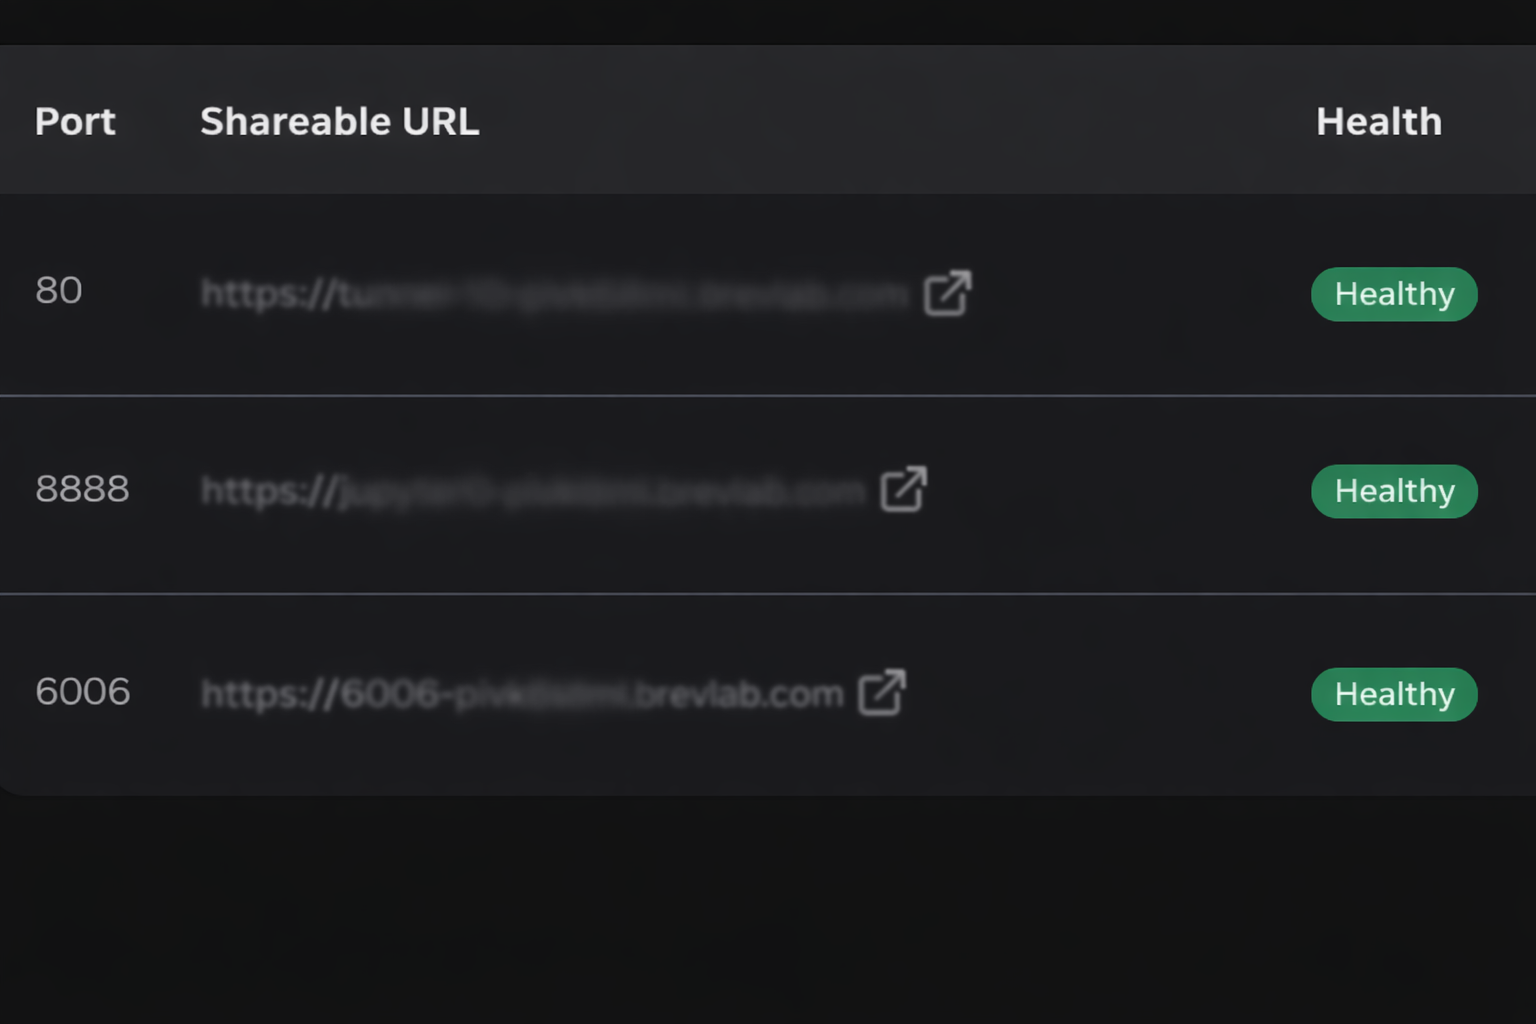

### Test the ACP Checkout Flow

1. **Select a product** from the catalog in the left panel
2. **Click "Buy Now"** to start the checkout flow
3. **Observe the promotion agent** decisions in the right panel (Agent Activity)
4. **Select shipping options** and proceed to payment
5. **Complete the delegated payment** flow
6. **View the order confirmation** and post-purchase updates from an agent

### Try Apps SDK Mode

Switch to the **Apps SDK** tab in the UI to experience the merchant-controlled checkout:

- **ARAG Recommendations Carousel**: Personalized product suggestions
- **Multi-item Shopping Cart**: Add multiple items before checkout
- **Same ACP Payment Flow**: Uses identical PSP integration, promotion and post-purchase messaging

### Key ACP Endpoints

| Endpoint | Method | Description |
|----------|--------|-------------|
| `/checkout_sessions` | POST | Create a new checkout session |
| `/checkout_sessions/{id}` | GET | Get session details with promotions |
| `/checkout_sessions/{id}` | POST | Update session (shipping, etc.) |
| `/checkout_sessions/{id}/complete` | POST | Complete checkout with payment |
| `/agentic_commerce/delegate_payment` | POST | Get vault token for delegated payment |
| `/products` | GET | List available products |

<a id="Service-Ports-Reference"></a>
## Service Ports Reference

### NVIDIA NIM Microservices (Local Deployment)

| Service | Container | External Port | Internal Port | Model |
|---------|-----------|---------------|---------------|-------|
| Nemotron Nano LLM | `nemotron-nano` | 8010 | 8000 | `nvidia/nemotron-3-nano` |
| Embedding Model | `embedqa` | 8011 | 8000 | `nvidia/nv-embedqa-e5-v5` |

<div class="alert alert-block alert-info">
    <b>Note:</b> NAT agents connect to NIMs via internal Docker network using container names (e.g., <code>http://nemotron-nano:8000/v1</code>). External ports (8010, 8011) are for health checks and debugging.
</div>

### Application Services

| Service | Port | Description |
|---------|------|-------------|
| nginx | 80 | Reverse proxy (main entry point) |
| Merchant API | 8000 | ACP checkout, products, orders |
| PSP Service | 8001 | Payment delegation, vault tokens |
| Apps SDK | 2091 | MCP server for AI agents |
| UI | 3000 | Next.js demo frontend |
| Promotion Agent | 8002 | Discount strategy (NAT) → uses local LLM |
| Post-Purchase Agent | 8003 | Multilingual messages (NAT) → uses local LLM |
| Recommendation Agent | 8004 | ARAG recommendations (NAT) → uses local LLM + embeddings |
| Search Agent | 8005 | RAG product search (NAT) → uses local LLM + embeddings |

### Infrastructure Services

| Service | Port | Description |
|---------|------|-------------|
| Milvus | 19530 | Vector database gRPC |
| Milvus Health | 9091 | Health check endpoint |
| Phoenix | 6006 | LLM tracing UI |
| MinIO Console | 9001 | Object storage UI |

<a id="Shutting-Down-Blueprint"></a>
## Shutting Down Blueprint

To shut down all microservices, run the following commands:

In [ ]:
# Stop application and infrastructure services
!docker compose -f docker-compose.infra.yml -f docker-compose.yml down > /dev/null 2>&1

# Stop NIM services
!docker compose -f docker-compose-nim.yml down > /dev/null 2>&1

To also remove all volumes (full cleanup including database data and NIM cache):

In [ ]:
# WARNING: This removes all data including the vector database, order history, and NIM cache
# !docker compose -f docker-compose.infra.yml -f docker-compose.yml down -v
# !docker compose -f docker-compose-nim.yml down -v